In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load all 6 files
fact = pd.read_csv('fact_table.csv', encoding='utf-8')
items = pd.read_csv('item_dim.csv', encoding='latin-1')
stores = pd.read_csv('store_dim.csv', encoding='latin-1')
time = pd.read_csv('time_dim.csv', encoding='latin-1')
customers = pd.read_csv('customer_dim.csv', encoding='latin-1')
payments = pd.read_csv('Trans_dim.csv', encoding='latin-1')

print("Fact Table:", fact.shape)
print("Items:", items.shape)
print("Stores:", stores.shape)
print("Time:", time.shape)
print("Customers:", customers.shape)
print("Payments:", payments.shape)

Fact Table: (1000000, 9)
Items: (264, 7)
Stores: (726, 4)
Time: (99999, 8)
Customers: (9191, 4)
Payments: (39, 3)


In [4]:
# Explore all tables
print("=== FACT TABLE ===")
print(fact.head(3))
print(fact.info())
print(fact.isnull().sum())

=== FACT TABLE ===
  payment_key coustomer_key time_key item_key store_key  quantity   unit  \
0        P026       C004510  T049189   I00177    S00307         1     ct   
1        P022       C008967  T041209   I00248    S00595         1  rolls   
2        P030       C007261   T03633   I00195    S00496         8     ct   

   unit_price  total_price  
0        35.0         35.0  
1        26.0         26.0  
2        12.5        100.0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   payment_key    1000000 non-null  object 
 1   coustomer_key  1000000 non-null  object 
 2   time_key       1000000 non-null  object 
 3   item_key       1000000 non-null  object 
 4   store_key      1000000 non-null  object 
 5   quantity       1000000 non-null  int64  
 6   unit           996277 non-null   object 
 7   unit_price     1000000 non-nul

In [5]:
print("\n=== ITEMS ===")
print(items.head(3))
print(items.isnull().sum())



=== ITEMS ===
  item_key                        item_name                desc  unit_price  \
0   I00001       A&W Root Beer - 12 oz cans  a. Beverage - Soda       11.50   
1   I00002  A&W Root Beer Diet - 12 oz cans  a. Beverage - Soda        6.75   
2   I00003    Barq's Root Beer - 12 oz cans  a. Beverage - Soda        6.75   

   man_country            supplier  unit  
0  Netherlands     Bolsius Boxmeer  cans  
1       poland  CHROMADURLIN S.A.S  cans  
2   Bangladesh        DENIMACH LTD  cans  
item_key       0
item_name      0
desc           0
unit_price     0
man_country    0
supplier       0
unit           1
dtype: int64


In [6]:

print("\n=== STORES ===")
print(stores.head(3))
print(stores.isnull().sum())



=== STORES ===
  store_key division  district     upazila
0     S0001   SYLHET  HABIGANJ  AJMIRIGANJ
1     S0002   SYLHET  HABIGANJ     BAHUBAL
2     S0003   SYLHET  HABIGANJ  BANIACHONG
store_key    0
division     0
district     0
upazila      0
dtype: int64


In [7]:

print("\n=== TIME ===")
print(time.head(3))
print(time.isnull().sum())



=== TIME ===
  time_key              date  hour  day      week  month quarter  year
0   T00001  20-05-2017 14:56    14   20  3rd Week      5      Q2  2017
1   T00002  30-01-2015 22:14    22   30  4th Week      1      Q1  2015
2   T00003  14-03-2020 02:34     2   14  2nd Week      3      Q1  2020
time_key    0
date        0
hour        0
day         0
week        0
month       0
quarter     0
year        0
dtype: int64


In [8]:

print("\n=== CUSTOMERS ===")
print(customers.head(3))
print(customers.isnull().sum())



=== CUSTOMERS ===
  coustomer_key           name     contact_no            nid
0       C000001          sumit  8801920345851  7505075708899
1       C000002       tammanne  8801817069329  1977731324842
2       C000003  kailash kumar  8801663795774  3769494056318
coustomer_key     0
name             27
contact_no        0
nid               0
dtype: int64


In [9]:

print("\n=== PAYMENTS ===")
print(payments.head(3))
print(payments.isnull().sum())


=== PAYMENTS ===
  payment_key trans_type                         bank_name
0        P001       cash                               NaN
1        P002       card                   AB Bank Limited
2        P003       card  Bangladesh Commerce Bank Limited
payment_key    0
trans_type     0
bank_name      1
dtype: int64


## Data Cleaning

### Issues Found:
1. **Fact Table** — `coustomer_key` spelling mistake, `unit` column mein 3,723 nulls
2. **Items** — `unit` column mein 1 null
3. **Customers** — `name` mein 27 nulls, `coustomer_key` spelling mistake
4. **Payments** — `bank_name` mein 1 null (cash transactions ka bank nahi hota)
5. **Time** — `date` column string format hai, datetime mein convert karna hai

### Cleaning Steps:
1. Column rename — `coustomer_key` → `customer_key`
2. Fact `unit` nulls → `unknown` se fill
3. Items `unit` null → drop
4. Customers `name` nulls → drop
5. Payments `bank_name` null → `Cash Payment` se fill
6. Time `date` → datetime convert

In [10]:
# 1. Column rename — spelling fix
fact.rename(columns={'coustomer_key': 'customer_key'}, inplace=True)
customers.rename(columns={'coustomer_key': 'customer_key'}, inplace=True)

In [11]:
# 2. Fact table — unit nulls fill
fact['unit'].fillna('unknown', inplace=True)

C:\Users\Ishwar\AppData\Local\Temp\ipykernel_11856\1746951019.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  fact['unit'].fillna('unknown', inplace=True)


In [12]:
# 3. Items — unit null drop (sirf 1 row)
items.dropna(subset=['unit'], inplace=True)


In [13]:
# 4. Customers — name nulls drop
customers.dropna(subset=['name'], inplace=True)

In [14]:
# 5. Payments — bank_name null fill
payments['bank_name'].fillna('Cash Payment', inplace=True)

C:\Users\Ishwar\AppData\Local\Temp\ipykernel_11856\4197655996.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  payments['bank_name'].fillna('Cash Payment', inplace=True)


In [15]:
# 6. Time — date column datetime convert
time['date'] = pd.to_datetime(time['date'], format='%d-%m-%Y %H:%M')


In [16]:
print("Cleaning done!")
print("Customers:", customers.shape)
print("Items:", items.shape)

Cleaning done!
Customers: (9164, 4)
Items: (263, 7)


In [17]:
# Verify cleaning
print("=== NULL CHECK AFTER CLEANING ===")
print("Fact unit nulls:", fact['unit'].isnull().sum())
print("Items unit nulls:", items['unit'].isnull().sum())
print("Customer name nulls:", customers['name'].isnull().sum())
print("Payment bank_name nulls:", payments['bank_name'].isnull().sum())
print("Time date type:", time['date'].dtype)

print("\n=== SHAPES AFTER CLEANING ===")
print("Fact:", fact.shape)
print("Customers:", customers.shape)
print("Items:", items.shape)

=== NULL CHECK AFTER CLEANING ===
Fact unit nulls: 0
Items unit nulls: 0
Customer name nulls: 0
Payment bank_name nulls: 0
Time date type: datetime64[ns]

=== SHAPES AFTER CLEANING ===
Fact: (1000000, 9)
Customers: (9164, 4)
Items: (263, 7)


In [18]:
# Master DataFrame banao
df = fact.merge(time, on='time_key', how='left')
df = df.merge(items, on='item_key', how='left')
df = df.merge(stores, on='store_key', how='left')
df = df.merge(customers, on='customer_key', how='left')
df = df.merge(payments, on='payment_key', how='left')

print("Master DataFrame Shape:", df.shape)
print(df.head(3))

Master DataFrame Shape: (1000000, 30)
  payment_key customer_key time_key item_key store_key  quantity unit_x  \
0        P026      C004510  T049189   I00177    S00307         1     ct   
1        P022      C008967  T041209   I00248    S00595         1  rolls   
2        P030      C007261   T03633   I00195    S00496         8     ct   

   unit_price_x  total_price                date  ...            supplier  \
0          35.0         35.0 2016-04-26 17:13:00  ...     Bolsius Boxmeer   
1          26.0         26.0 2018-06-11 19:08:00  ...        DENIMACH LTD   
2          12.5        100.0 2016-11-19 08:19:00  ...  CHROMADURLIN S.A.S   

   unit_y    division  district     upazila           name    contact_no  \
0      ct       DHAKA  JAMALPUR    ISLAMPUR          priya  8.801529e+12   
1   rolls       DHAKA     DHAKA  CANTONMENT  harpreet kaur  8.801985e+12   
2      ct  CHITTAGONG  NOAKHALI   BEGUMGANJ          sonam  8.801956e+12   

            nid  trans_type                bank

In [19]:
# unit_x aur unit_price_x clean karo
df.drop(columns=['unit_y', 'unit_price_y'], inplace=True)
df.rename(columns={
    'unit_x': 'unit',
    'unit_price_x': 'unit_price'
}, inplace=True)

print("Columns:", df.columns.tolist())
print("Shape:", df.shape)

Columns: ['payment_key', 'customer_key', 'time_key', 'item_key', 'store_key', 'quantity', 'unit', 'unit_price', 'total_price', 'date', 'hour', 'day', 'week', 'month', 'quarter', 'year', 'item_name', 'desc', 'man_country', 'supplier', 'division', 'district', 'upazila', 'name', 'contact_no', 'nid', 'trans_type', 'bank_name']
Shape: (1000000, 28)


## EDA — Exploratory Data Analysis

### Business Questions:
1. Total Revenue kitna hai?
2. Yearly Sales Trend kya hai?
3. Top 10 Products by Revenue?
4. Top Divisions by Sales?
5. Most Used Payment Method?
6. Monthly Sales Trend?
7. Top Suppliers?
8. Peak Hour Analysis?

In [20]:
# 1. Basic Stats
print("Total Revenue: ", df['total_price'].sum())
print("Total Orders: ", len(df))
print("Total Customers: ", df['customer_key'].nunique())
print("Total Products: ", df['item_key'].nunique())
print("Total Stores: ", df['store_key'].nunique())
print("Date Range: ", df['date'].min(), "to", df['date'].max())

Total Revenue:  105401435.75
Total Orders:  1000000
Total Customers:  9191
Total Products:  264
Total Stores:  726
Date Range:  2014-01-20 14:06:00 to 2021-01-23 04:38:00


### Key Stats:
- Total Revenue: ₹105.4 Million
- Total Orders: 1,000,000
- Total Customers: 9,191
- Total Products: 264
- Total Stores: 726
- Date Range: 2014 to 2021 (7 years of data)

C:\Users\Ishwar\AppData\Local\Temp\ipykernel_11856\187561019.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=yearly, x='year', y='total_price', palette='Blues_d')


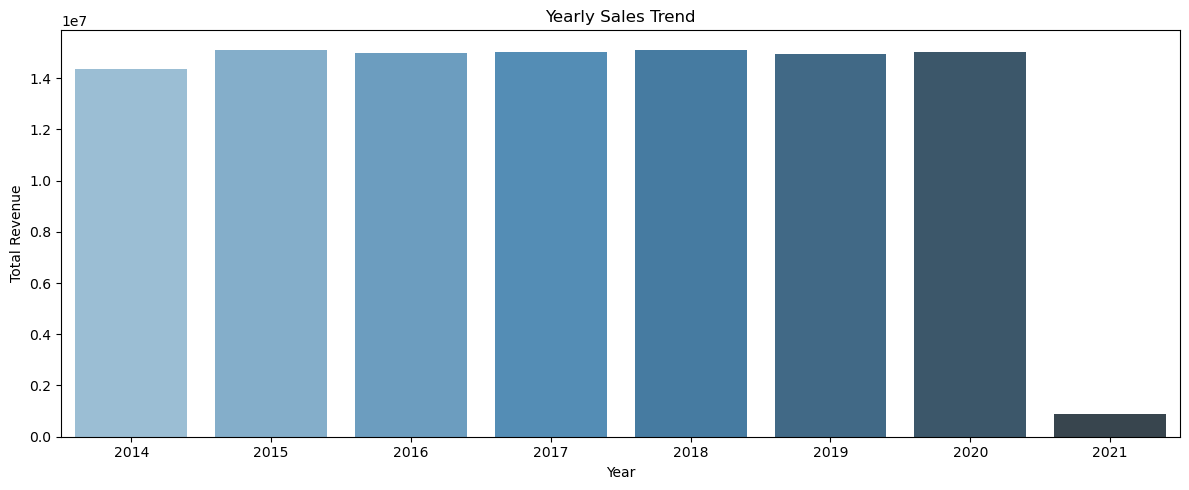

In [21]:
# 1. Yearly Sales Trend
plt.figure(figsize=(12,5))
yearly = df.groupby('year')['total_price'].sum().reset_index()
sns.barplot(data=yearly, x='year', y='total_price', palette='Blues_d')
plt.title('Yearly Sales Trend')
plt.xlabel('Year')
plt.ylabel('Total Revenue')
plt.tight_layout()
plt.show()

### 1. Yearly Sales Trend
- Revenue remains consistent from 2014-2020 (~15M per year)
- 2021 shows a significant drop — incomplete year data (only Jan 2021)
- No major growth trend observed — stable business performance

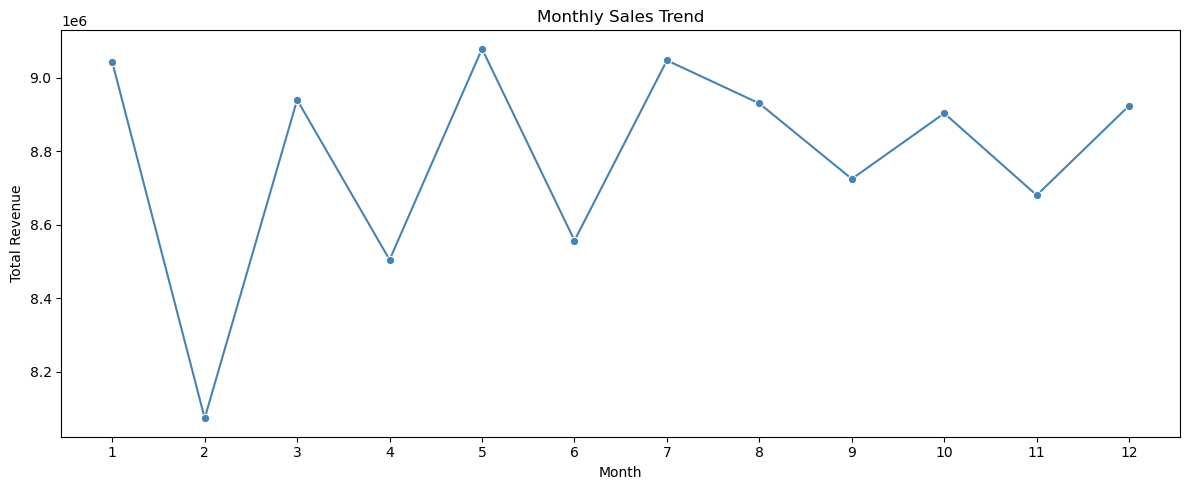

In [22]:
# 2. Monthly Sales Trend
plt.figure(figsize=(12,5))
monthly = df.groupby('month')['total_price'].sum().reset_index()
sns.lineplot(data=monthly, x='month', y='total_price', marker='o', color='steelblue')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(range(1,13))
plt.tight_layout()
plt.show()

### 2. Monthly Sales Trend
- May (Month 5) and July (Month 7) are peak sales months
- February (Month 2) has lowest revenue — significant dip
- Overall monthly revenue ranges between 8.1M - 9.1M
- No strong seasonal pattern observed

C:\Users\Ishwar\AppData\Local\Temp\ipykernel_11856\522734980.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_products, x='total_price', y='item_name', palette='Greens_d')
C:\Users\Ishwar\AppData\Local\Temp\ipykernel_11856\522734980.py:8: UserWarning: Glyph 150 (\x96) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Ishwar\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 150 (\x96) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


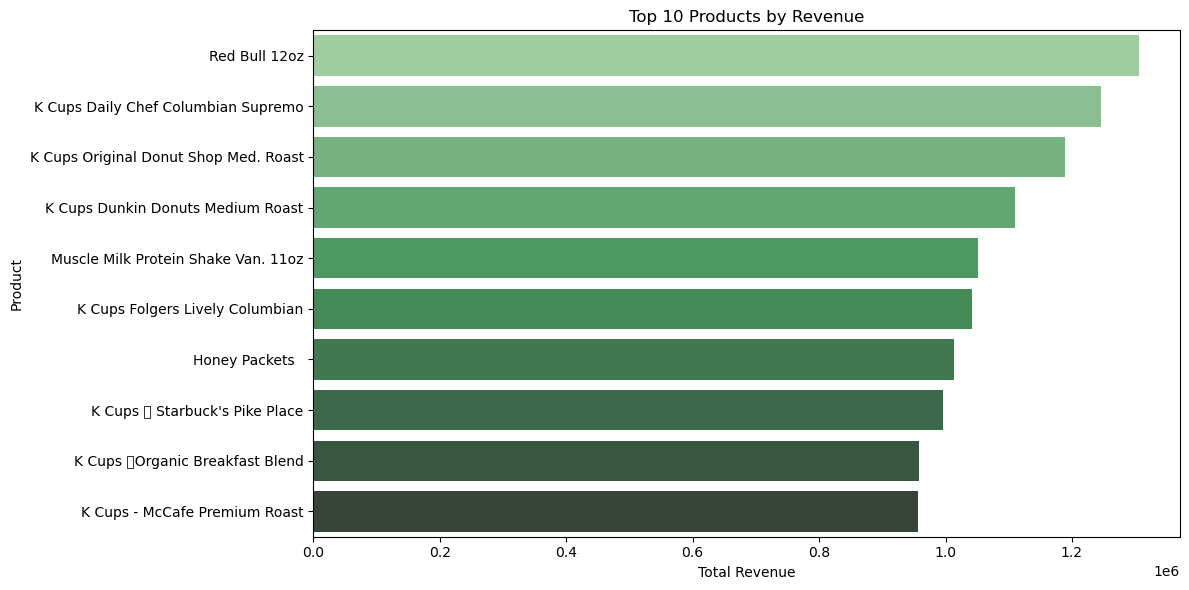

In [23]:
# 3. Top 10 Products by Revenue
plt.figure(figsize=(12,6))
top_products = df.groupby('item_name')['total_price'].sum().nlargest(10).reset_index()
sns.barplot(data=top_products, x='total_price', y='item_name', palette='Greens_d')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

### 3. Top 10 Products by Revenue
- Red Bull 12oz is the highest revenue product (~1.3M)
- K Cups (Coffee products) dominate top 10 — 7 out of 10
- Muscle Milk Protein Shake is the only non-coffee/energy product
- Beverage category clearly drives maximum revenue

C:\Users\Ishwar\AppData\Local\Temp\ipykernel_11856\1517904670.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_div, x='total_price', y='division', palette='Oranges_d')


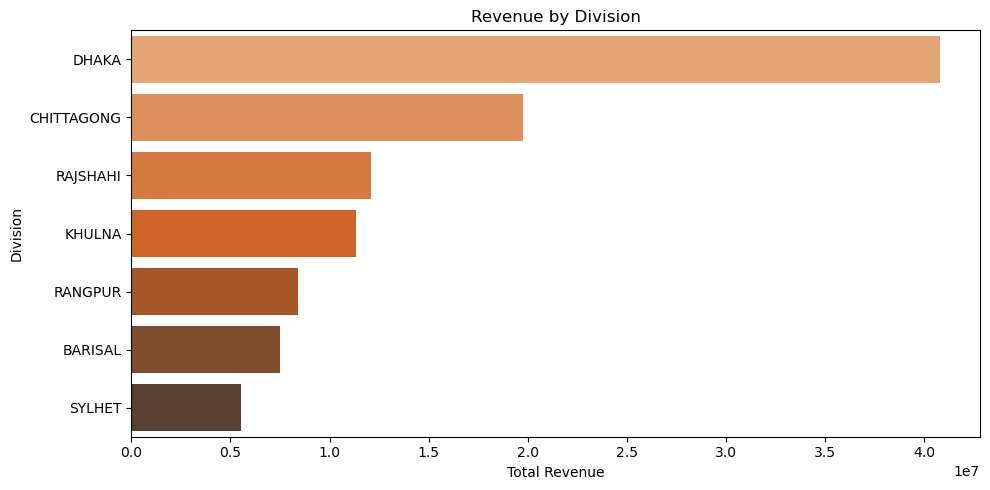

In [24]:
# 4. Top Divisions by Revenue
plt.figure(figsize=(10,5))
top_div = df.groupby('division')['total_price'].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=top_div, x='total_price', y='division', palette='Oranges_d')
plt.title('Revenue by Division')
plt.xlabel('Total Revenue')
plt.ylabel('Division')
plt.tight_layout()
plt.show()

### 4. Revenue by Division
- DHAKA dominates with ~40M revenue — almost 2x of Chittagong
- CHITTAGONG is second with ~20M
- SYLHET has lowest revenue (~5M)
- Significant gap between Dhaka and other divisions
- Business should focus more resources on underperforming divisions

C:\Users\Ishwar\AppData\Local\Temp\ipykernel_11856\1144141266.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=payment, x='trans_type', y='total_price', palette='Purples_d')


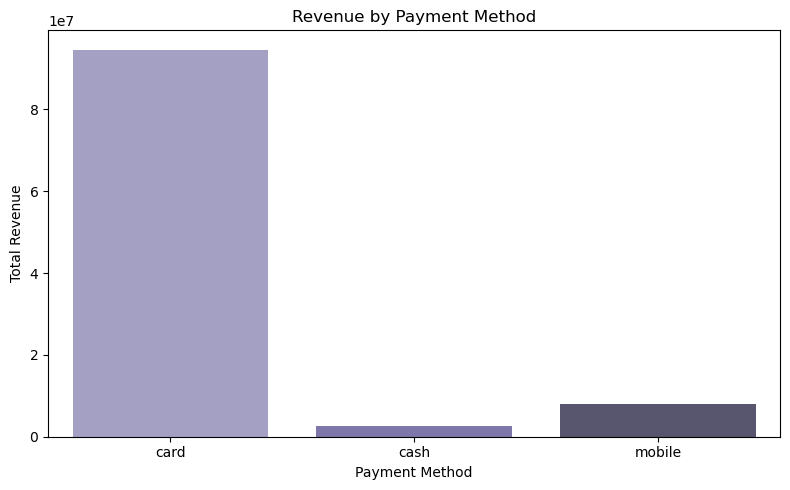

In [25]:
# 5. Payment Method Distribution
plt.figure(figsize=(8,5))
payment = df.groupby('trans_type')['total_price'].sum().reset_index()
sns.barplot(data=payment, x='trans_type', y='total_price', palette='Purples_d')
plt.title('Revenue by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Total Revenue')
plt.tight_layout()
plt.show()

### 5. Revenue by Payment Method
- Card payments dominate massively (~93M out of 105M total)
- Mobile payments second (~8M)
- Cash payments lowest (~2M)
- KEY FINDING: 88% of revenue comes from card payments
- Business is heavily card-dependent — digital payment adoption is high

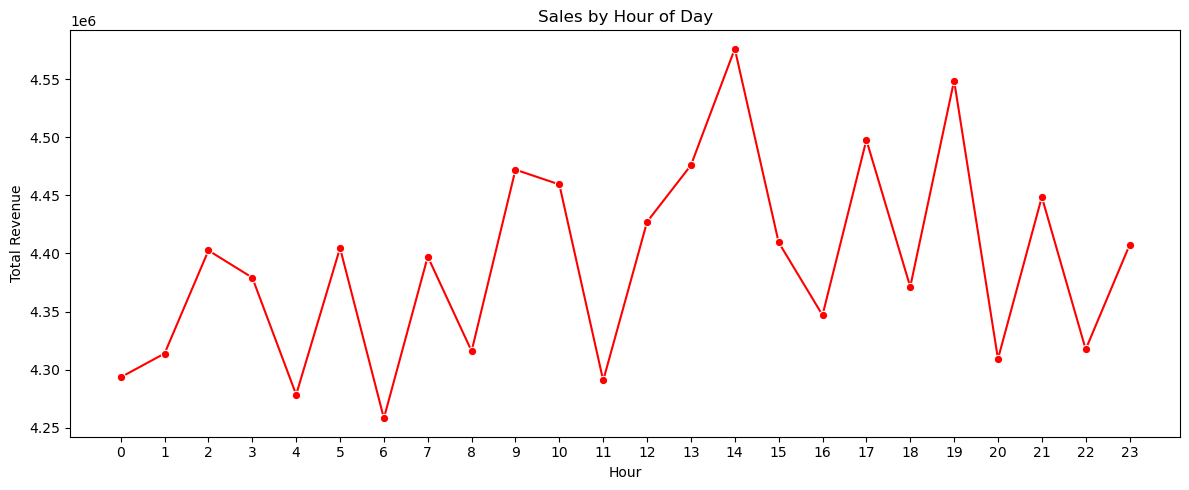

In [26]:
# 6. Peak Hour Analysis
plt.figure(figsize=(12,5))
hourly = df.groupby('hour')['total_price'].sum().reset_index()
sns.lineplot(data=hourly, x='hour', y='total_price', marker='o', color='red')
plt.title('Sales by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Total Revenue')
plt.xticks(range(0,24))
plt.tight_layout()
plt.show()

### 6. Sales by Hour of Day
- Hour 14 (2 PM) is peak sales hour
- Hour 19 (7 PM) is second peak
- Hour 11 (11 AM) and Hour 6 (6 AM) are lowest
- Sales are relatively consistent throughout the day
- No major dead hours — store operates 24/7

C:\Users\Ishwar\AppData\Local\Temp\ipykernel_11856\4153505595.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_suppliers, x='total_price', y='supplier', palette='Blues_d')


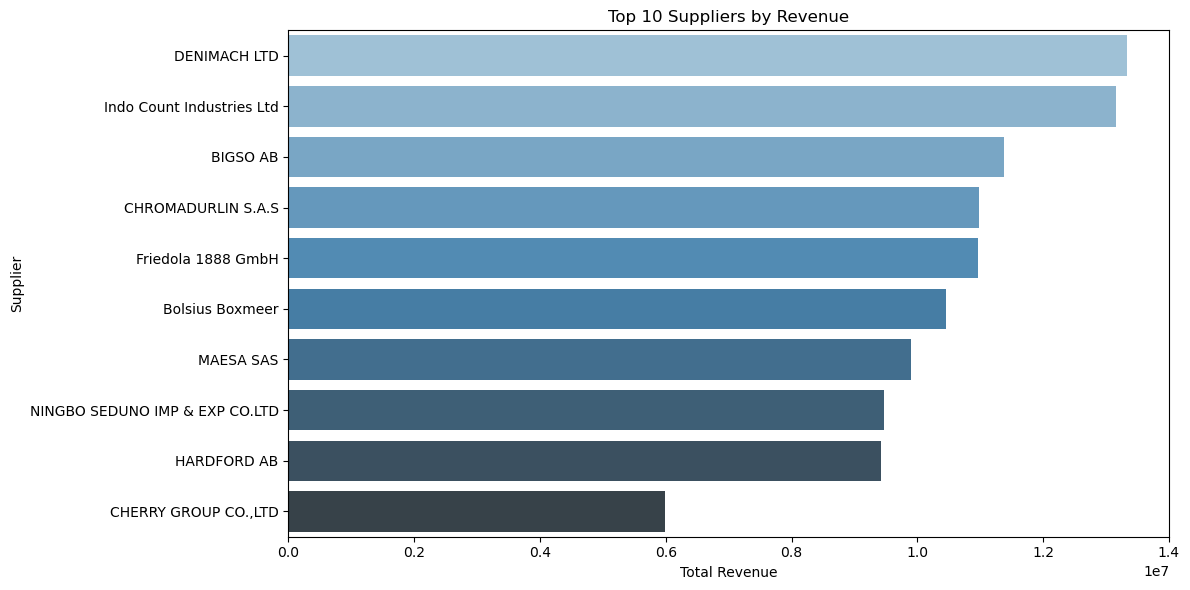

In [27]:
# 7. Top 10 Suppliers by Revenue
plt.figure(figsize=(12,6))
top_suppliers = df.groupby('supplier')['total_price'].sum().nlargest(10).reset_index()
sns.barplot(data=top_suppliers, x='total_price', y='supplier', palette='Blues_d')
plt.title('Top 10 Suppliers by Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Supplier')
plt.tight_layout()
plt.show()

### 7. Top 10 Suppliers by Revenue
- DENIMACH LTD is top supplier (~13.5M)
- Indo Count Industries Ltd is close second (~13M)
- Top 2 suppliers contribute ~25% of total revenue
- CHERRY GROUP CO.,LTD has significantly lower revenue than others
- International suppliers dominate — global supply chain

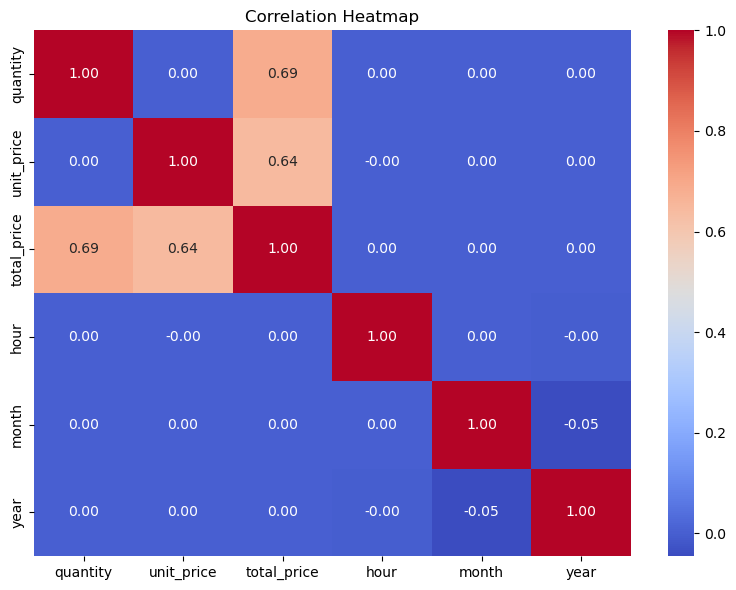

In [28]:
# 8. Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df[['quantity','unit_price','total_price','hour','month','year']].corr(),
            annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

### 8. Correlation Heatmap
- quantity & total_price → 0.69 (strong positive)
  More quantity = more revenue (obvious but confirmed)
- unit_price & total_price → 0.64 (moderate positive)
  Higher priced items contribute more to revenue
- hour, month, year → no correlation with sales
  Time does NOT significantly impact revenue
- KEY FINDING: Revenue is driven by quantity and unit price,
  not by time of day or season

## Final EDA Summary

### Dataset: 1M transactions | 2014-2021 | Retail Store

### Key Findings:
1. Total Revenue: $105.4M across 7 years
2. Revenue is stable at ~15M per year (2015-2020)
3. Red Bull 12oz is the highest revenue product
4. Beverage & Coffee products dominate top 10
5. DHAKA division contributes ~38% of total revenue
6. Card payments = 88% of all transactions
7. Peak sales hour is 2 PM (Hour 14)
8. DENIMACH LTD is top supplier
9. May and July are peak sales months
10. Quantity and unit price drive revenue, not time

In [29]:
# Export cleaned CSVs
time.to_csv('time_dim_clean.csv', index=False)
items.to_csv('item_dim_clean.csv', index=False)
customers.to_csv('customer_dim_clean.csv', index=False)
fact.to_csv('fact_table_clean.csv', index=False)